In [57]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

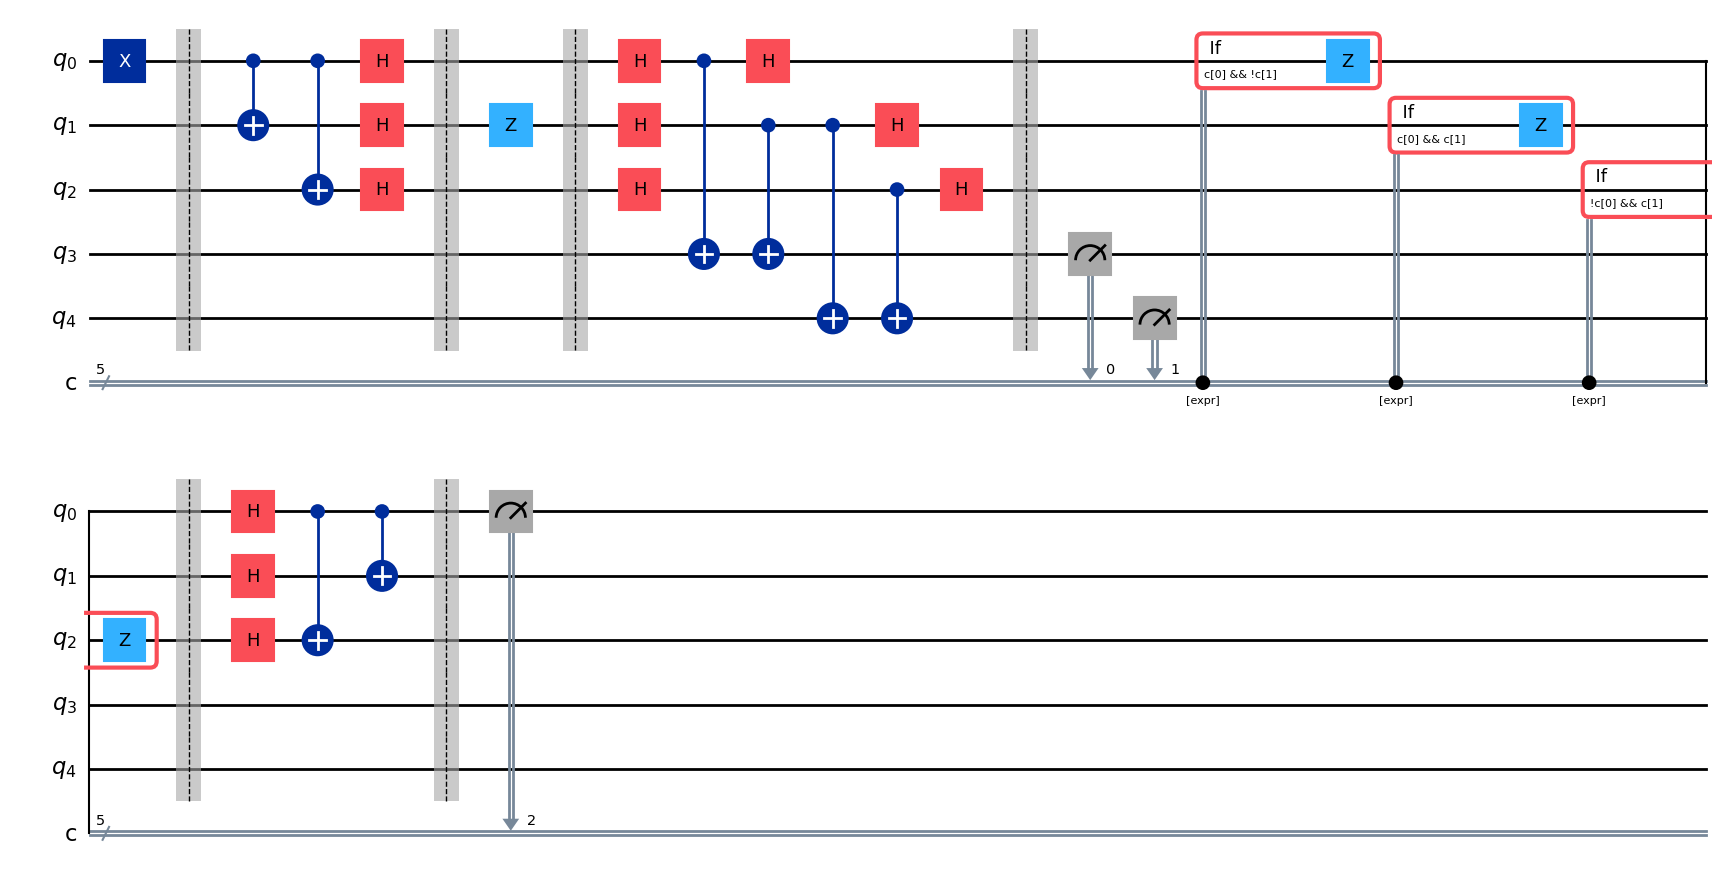

In [76]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Three qubit phase-flip error-correcting code

# In a similar way to the bit-flip error-correcting code, implement the phase-flip error-correcting code.
# Check that the code can correct a single phase flip but not two or more simultaneous phase flips.
# What happens if you introduce a bit flip?
# The next cell still has the simulation and measurement. Implement the phase flip code on the same qubits
# as for the bit flip code, so you can reuse the simulation and measurement.


flip = QuantumCircuit(5,5)

flip.x(0)

flip.barrier()


flip.cx(0,1)
flip.cx(0,2)

flip.h(0)
flip.h(1)
flip.h(2)


flip.barrier()

flip.z(1)


flip.barrier()

flip.h(0)
flip.h(1)
flip.h(2)

flip.cx(0,3)
flip.cx(1,3)
flip.cx(1,4)
flip.cx(2,4)

flip.h(0)
flip.h(1)
flip.h(2)

flip.barrier()

flip.measure([3,4],[0,1])


with flip.if_test(expr.logic_and(flip.clbits[0],expr.logic_not(flip.clbits[1]))):
    flip.z(0)

with flip.if_test(expr.logic_and(flip.clbits[0],flip.clbits[1])):
    flip.z(1)

with flip.if_test(expr.logic_and(expr.logic_not(flip.clbits[0]),flip.clbits[1])):
    flip.z(2)

flip.barrier()

flip.h(0)
flip.h(1)
flip.h(2)

flip.cx(0,2)
flip.cx(0,1)

flip.barrier()

# You can also implement the final decoding, putting the state back into a single qubit, and measuring it.

flip.measure([0],[2])

# Check the circuit

flip.draw("mpl")


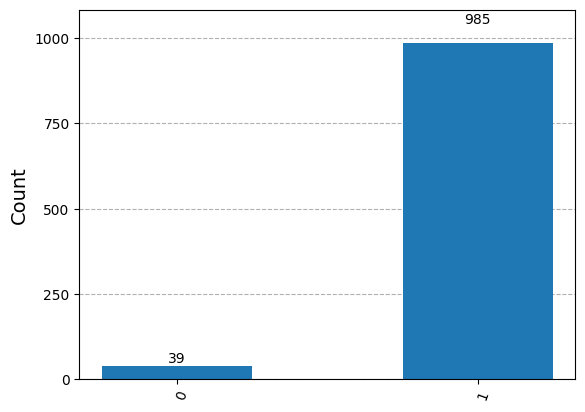

In [77]:
# Simulate and plot results

backend = GenericBackendV2(num_qubits=5, control_flow=True)
compiled = transpile(flip, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
# We only want to see the results for bits 2, 3, 4
mcounts = marginal_counts(counts,indices=[2])
plot_histogram(mcounts)